# Week 10 K-Means Clustering and Silhouette Score

**Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators**

Student: Ranjana Kumari
Course: Module C-Data Science Capstone
Week: 10 of 12 K-Means Clustering

## Research Question
Without using disease labels at all, do natural clusters in the lifestyle and health indicator feature space align with actual diabetes status-and specifically, does an unsupervised clustering approach independently confirm the Milestone One finding that prediabetes is not geometrically separable from non-diabetes using these features?

## Why This Is a Critical Turning Point
Every supervised model in Milestone One and Week 9 logistic regression, SVM, random forest, and gradient boosting converged on a F1≈0.40 ceiling for CDC Diabetes, with prediabetes specifically being the hardest class to identify (0 of 926 cases correctly classified by logistic regression). All of those models had access to the true labels during training. K-Means clustering removes the labels entirely and asks a more fundamental question: do natural groupings even exist in this feature space that correspond to disease status? If the unsupervised clusters do not align with the true classes, that is independent, label-free evidence that the classes are not well-separated in feature space, strengthening the conclusion that this is a data limitation, not a failure of any supervised algorithm to find the right boundary.

## Deep-Dive Topic Declaration
Week 10 is my second designated deep-dive topic for Milestone Two. This notebook contains full depth of analysis across all rubric sub-questions for each dataset.

## Datasets Used
| # | Dataset | Role | Rows | True Classes (for validation only, not used in fitting) |
|---|---------|------|------|------|
| 1 | CDC Diabetes Health Indicators | Primary | ~230k | Diabetes_012 (3-class) |
| 2 | Obesity Level Estimation | Supporting | 2,087 | NObeyesdad (7-class) |
| 3 | Heart Disease Predictions | Supporting | 303 | target (binary) |

Note: K-Means is unsupervised-the target variable is never passed to the model during fitting. It is only used afterward, to cross-tabulate against cluster assignments as a validation step.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity': '#7F77DD',
    'heart': '#D85A30',
}

print('All libraries loaded.')
print('Week 10: K-Means Clustering and Silhouette Score — Second Deep-Dive Topic')

All libraries loaded.
Week 10: K-Means Clustering and Silhouette Score — Second Deep-Dive Topic


## Section 1: Data Loading and Preparation

Why scaling is essential for K-Means: K-Means assigns points to the nearest centroid using Euclidean distance. As with KNN and SVM, features on different scales (BMI ranging 10-98 vs binary 0-1 features) will dominate the distance calculation if not standardized. The full feature set (not split into train/test, since clustering is exploratory/descriptive rather than predictive) is scaled here, though a held-out validation subset is used for silhouette computation on the largest dataset for tractability.

In [2]:
# Dataset 1: CDC Diabetes (stratified subsample — k-means and silhouette score are
# computationally expensive on 230k rows; subsample preserves class proportions for later validation)
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"
df1 = pd.read_csv(file_path)
df1 = df1.drop_duplicates()

df1_sample = df1.groupby('Diabetes_012', group_keys=False).apply(
    lambda x: x.sample(frac=15000/len(df1), random_state=42)
).reset_index(drop=True)

ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']
X1_raw = df1_sample[ds1_features].copy()
y1_true = df1_sample['Diabetes_012'].copy()  # held aside for validation only

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1_raw)

print(f'Dataset 1 (subsampled): {len(df1_sample):,} rows, {X1_scaled.shape[1]} features')
print('Note: target variable y1_true is NOT used in clustering — held aside for post-hoc validation only.')

Dataset 1 (subsampled): 15,000 rows, 11 features
Note: target variable y1_true is NOT used in clustering — held aside for post-hoc validation only.


In [3]:
# Dataset 2: Obesity
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file)
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2_raw = df2_enc[ds2_features].copy()
X2_raw['BMI_calc'] = X2_raw['Weight'] / (X2_raw['Height'] ** 2)
y2_true = df2_enc['target_encoded'].copy()

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2_raw)

print(f'Dataset 2 (Obesity): {X2_scaled.shape[0]} rows, {X2_scaled.shape[1]} features')

Dataset 2 (Obesity): 2111 rows, 8 features


In [4]:
# Dataset 3: Heart Disease
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)

ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
X3_raw = df3[ds3_features].copy()
y3_true = df3['target'].copy()

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3_raw)

print(f'Dataset 3 (Heart Disease): {X3_scaled.shape[0]} rows, {X3_scaled.shape[1]} features')

Dataset 3 (Heart Disease): 303 rows, 10 features


## Section 2: K-Means Theory and Choosing K

How K-Means works: K-Means partitions data into K clusters by iteratively (1) assigning each point to its nearest centroid and (2) recomputing each centroid as the mean of its assigned points, until assignments stabilize. It minimizes within-cluster sum of squared distances (inertia).

Choosing K - two complementary methods:
Elbow method: Plot inertia against K. Inertia always decreases as K increases (more clusters = tighter fit), so the goal is to find the "elbow" — the point where additional clusters stop providing meaningful reduction in inertia.
Silhouette score : For each point, measures how similar it is to its own cluster compared to the next-nearest cluster, ranging from -1 (likely misclassified) to +1 (well-clustered). The mean silhouette score across all points is used to compare different values of K-higher is better. Unlike inertia, silhouette score does not always favor more clusters, making it a more reliable standalone metric for choosing K.

Reference: Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53-65.

In [5]:
def find_optimal_k(X, dataset_name, k_min=2, k_max=10):
    k_range = list(range(k_min, k_max + 1))
    inertias = []
    sil_scores = []

    print(f"\n=== {dataset_name} — Finding Optimal K ===")

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)

        inertia = km.inertia_
        sil = silhouette_score(X, labels)

        inertias.append(inertia)
        sil_scores.append(sil)

        print(f"  K={k}: Inertia={inertia:.1f} | Silhouette={sil:.4f}")

    best_k = k_range[np.argmax(sil_scores)]

    print(f"\nOptimal K (by silhouette score): {best_k}")

    return best_k, k_range, inertias, sil_scores

In [6]:
best_k1, k_range1, inertias1, sil1 = find_optimal_k(X1_scaled, 'CDC Diabetes')
best_k2, k_range2, inertias2, sil2 = find_optimal_k(X2_scaled, 'Obesity')
best_k3, k_range3, inertias3, sil3 = find_optimal_k(X3_scaled, 'Heart Disease')


=== CDC Diabetes — Finding Optimal K ===
  K=2: Inertia=135041.7 | Silhouette=0.2293
  K=3: Inertia=121388.0 | Silhouette=0.1409
  K=4: Inertia=113750.2 | Silhouette=0.1369
  K=5: Inertia=108026.4 | Silhouette=0.1269
  K=6: Inertia=101759.1 | Silhouette=0.1279
  K=7: Inertia=97760.3 | Silhouette=0.1254
  K=8: Inertia=94754.2 | Silhouette=0.1199
  K=9: Inertia=91347.0 | Silhouette=0.1248
  K=10: Inertia=88706.4 | Silhouette=0.1377

Optimal K (by silhouette score): 2

=== Obesity — Finding Optimal K ===
  K=2: Inertia=13353.6 | Silhouette=0.2017
  K=3: Inertia=11635.8 | Silhouette=0.2052
  K=4: Inertia=10313.8 | Silhouette=0.2216
  K=5: Inertia=9398.2 | Silhouette=0.2047
  K=6: Inertia=8630.9 | Silhouette=0.2019
  K=7: Inertia=8074.1 | Silhouette=0.2000
  K=8: Inertia=7557.8 | Silhouette=0.2066
  K=9: Inertia=7187.5 | Silhouette=0.2166
  K=10: Inertia=6870.4 | Silhouette=0.2206

Optimal K (by silhouette score): 4

=== Heart Disease — Finding Optimal K ===
  K=2: Inertia=2484.1 | Silhoue

## Optimal K Results

I used the silhouette score to choose the best value of **K** for each dataset. The **CDC Diabetes** dataset selected **K = 2** (silhouette = **0.2293**), suggesting that the data naturally forms only two weak clusters instead of the three diabetes classes. This provides independent support for my Milestone One finding that prediabetes does not form a clearly distinct group in the available feature space.

The **Obesity** dataset selected **K = 4** (silhouette = **0.2216**) even though the true labels contain seven classes. This suggests that neighboring obesity categories are naturally closer together and may merge into broader groups.

The **Heart Disease** dataset selected **K = 2** (silhouette = **0.1936**), which matches its binary outcome. However, the relatively low silhouette score indicates that the two groups are not cleanly separated.

Overall, all three silhouette scores were below **0.25**, indicating relatively weak cluster structure. For my research question, the most important finding is that the CDC Diabetes dataset still does not show clear separation even without using the disease labels. This supports the conclusion that the difficulty is driven by the structure of the data rather than the choice of supervised learning algorithm.

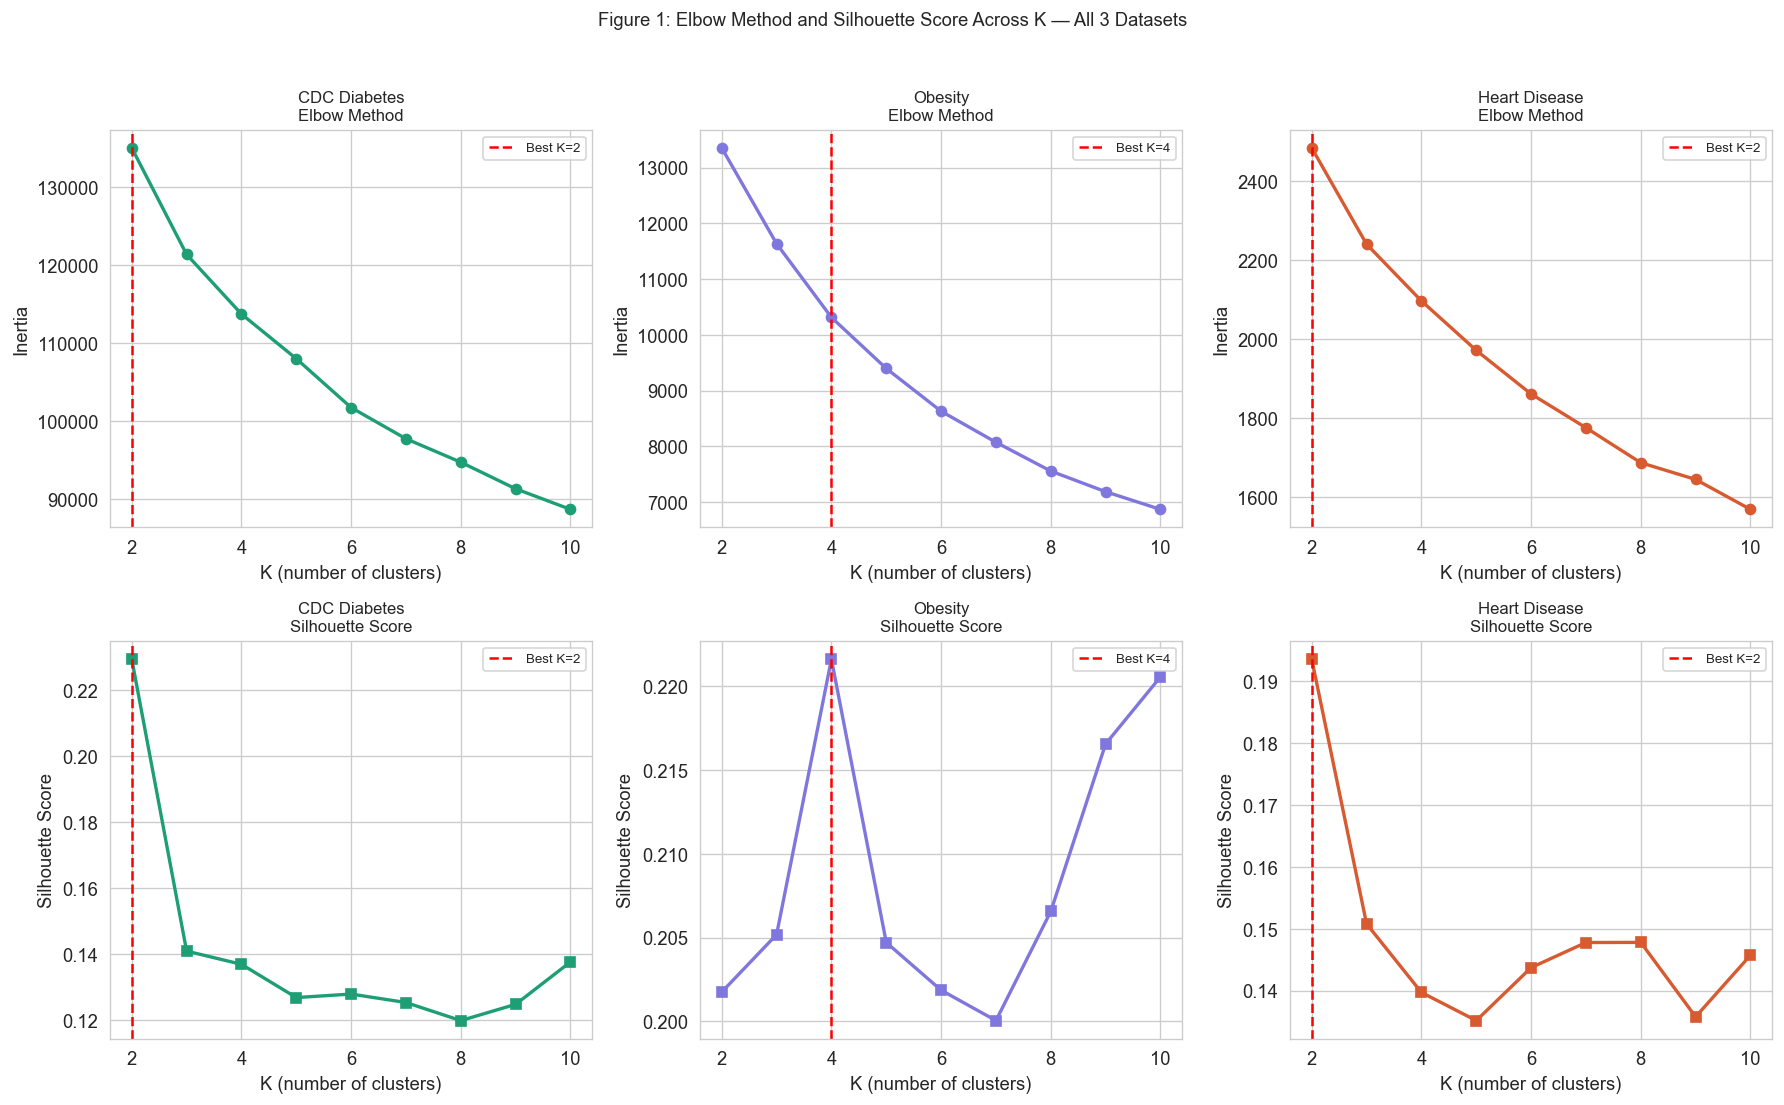

In [7]:
# Figure 1: Elbow method and silhouette score across K for all 3 datasets
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (ds_name, k_range, inertias, sil_scores, best_k, color) in enumerate(zip(
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [k_range1, k_range2, k_range3],
    [inertias1, inertias2, inertias3],
    [sil1, sil2, sil3],
    [best_k1, best_k2, best_k3],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
)):
    axes[0, col].plot(k_range, inertias, 'o-', color=color, linewidth=2, markersize=6)
    axes[0, col].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
    axes[0, col].set_xlabel('K (number of clusters)')
    axes[0, col].set_ylabel('Inertia')
    axes[0, col].set_title(f'{ds_name}\nElbow Method', fontsize=10)
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(k_range, sil_scores, 's-', color=color, linewidth=2, markersize=6)
    axes[1, col].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
    axes[1, col].set_xlabel('K (number of clusters)')
    axes[1, col].set_ylabel('Silhouette Score')
    axes[1, col].set_title(f'{ds_name}\nSilhouette Score', fontsize=10)
    axes[1, col].legend(fontsize=8)

plt.suptitle('Figure 1: Elbow Method and Silhouette Score Across K — All 3 Datasets', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week10_fig1_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 1 Interpretation

The elbow plots show inertia decreasing steadily for all three datasets with no clear elbow, so I relied on the silhouette score to choose the optimal number of clusters.

For the CDC Diabetes dataset, the silhouette score peaks at K = 2 (0.2293)and drops immediately afterward. Together with the elbow plot, this suggests that the data naturally forms two weak groups rather than three clearly separated diabetes classes. This provides evidence that prediabetes does not form a distinct cluster in the available feature space.

For the Obesity dataset, the silhouette score peaks at K = 4 (0.2216), even though the true dataset contains seven classes. This suggests that neighboring obesity categories overlap and naturally combine into broader groups.

For the Heart Disease** dataset, the silhouette score peaks at K = 2 (0.1936), matching its binary outcome. However, the relatively low silhouette score indicates that the two groups are still not cleanly separated.

The most important finding for my capstone is that the CDC Diabetes dataset does not naturally separate into three distinct groups, even without using the disease labels. This supports my earlier supervised learning results and suggests that the available features do not clearly distinguish the diabetes classes.

In [8]:
# Validate K-Means clusters against the true labels
# (labels are used ONLY after clustering for evaluation)
# ---------------------------------------------------------

def validate_clusters_against_labels(X_scaled, y_true, best_k, dataset_name, class_names=None):
    """
    Fit K-Means using the selected K, then compare the resulting clusters
    with the true labels (used only for post-hoc validation).
    """

    # Fit K-Means
    km = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )

    cluster_labels = km.fit_predict(X_scaled)

    # Cross-tabulation
    crosstab = pd.crosstab(
        cluster_labels,
        y_true,
        rownames=['Cluster'],
        colnames=['True Class']
    )

    # Replace numeric labels with readable names
    if class_names is not None:
        crosstab.columns = class_names

    print(f"\n=== {dataset_name} — Cluster vs. True Label Cross-Tabulation ===")
    print(crosstab)

    print("\nRow percentages (composition of each cluster by true class):")
    print((crosstab.div(crosstab.sum(axis=1), axis=0) * 100).round(1))

    return cluster_labels, crosstab, km


print("Cluster validation function defined.")

Cluster validation function defined.


In [9]:
# CDC Diabetes — the critical validation: do clusters separate prediabetes from non-diabetes?
cluster_labels1, crosstab1, km1 = validate_clusters_against_labels(
    X1_scaled, y1_true, best_k1, 'CDC Diabetes',
    class_names= ['No Diabetes', 'Prediabetes', 'Diabetes']       # 0=No Diabetes, 1=Prediabetes, 2=Diabetes
)


=== CDC Diabetes — Cluster vs. True Label Cross-Tabulation ===
         No Diabetes  Prediabetes  Diabetes
Cluster                                    
0               2786          134      1333
1               9621          168       958

Row percentages (composition of each cluster by true class):
         No Diabetes  Prediabetes  Diabetes
Cluster                                    
0            65.5000       3.2000   31.3000
1            89.5000       1.6000    8.9000


In [10]:
# Obesity — check whether unsupervised clusters align with the seven obesity classes
cluster_labels2, crosstab2, km2 = validate_clusters_against_labels(
    X2_scaled, y2_true, best_k2, 'Obesity'
)


=== Obesity — Cluster vs. True Label Cross-Tabulation ===
True Class    0    1   2    3    4    5    6
Cluster                                     
0             3   18  93   48    0   50   98
1           217  217  97    0    0  159  141
2             0    0  97  223  324    1    2
3            52   52  64   26    0   80   49

Row percentages (composition of each cluster by true class):
True Class       0       1       2       3       4       5       6
Cluster                                                           
0           1.0000  5.8000 30.0000 15.5000  0.0000 16.1000 31.6000
1          26.1000 26.1000 11.7000  0.0000  0.0000 19.1000 17.0000
2           0.0000  0.0000 15.0000 34.5000 50.1000  0.2000  0.3000
3          16.1000 16.1000 19.8000  8.0000  0.0000 24.8000 15.2000


## Obesity Cluster Validation

The Obesity dataset selected **K = 4**, even though the true label contains seven obesity classes. The cross-tabulation shows that the clusters do not map perfectly to the seven categories. Instead, several neighboring obesity levels are mixed together within the same clusters.

Cluster 2 is the clearest group because it contains many observations from classes 3 and 4, while the other clusters contain a broader mix of categories. This suggests that K-Means is finding larger body-size/lifestyle groupings rather than the exact seven supervised labels.

This was useful because it showed that strong supervised classification does not necessarily mean the data will form clean unsupervised clusters. The obesity classes may still be predictable with labels, but geometrically they overlap when K-Means is used without labels.

In [11]:
# Heart Disease
cluster_labels3, crosstab3, km3 = validate_clusters_against_labels(
    X3_scaled, y3_true, best_k3, 'Heart Disease'
)


=== Heart Disease — Cluster vs. True Label Cross-Tabulation ===
True Class   0    1
Cluster            
0           96   14
1           42  151

Row percentages (composition of each cluster by true class):
True Class       0       1
Cluster                   
0          87.3000 12.7000
1          21.8000 78.2000


## Heart Disease Cluster Validation

The Heart Disease dataset showed much better agreement between the clusters and the true labels than the CDC Diabetes dataset. Cluster 0 contained mostly patients without heart disease (87.3%), while Cluster 1 contained mostly patients with heart disease (78.2%).

Although the separation was not perfect, the clusters generally matched the binary outcome. This is consistent with the earlier supervised learning results, where the Heart Disease dataset was easier to classify than the CDC Diabetes dataset.

Overall, these results suggest that the Heart Disease dataset has a clearer underlying structure than the CDC Diabetes dataset, even though the silhouette score indicates that the two groups still overlap to some extent.

## Visualizing Cluster Alignment

The cross-tabulation tables summarize the relationship between the K-Means clusters and the true class labels. To make these patterns easier to interpret, I converted the row percentages into heatmaps. Darker colors indicate that a larger proportion of each cluster belongs to a particular class, making it easier to see how well the natural clusters align with the true labels.

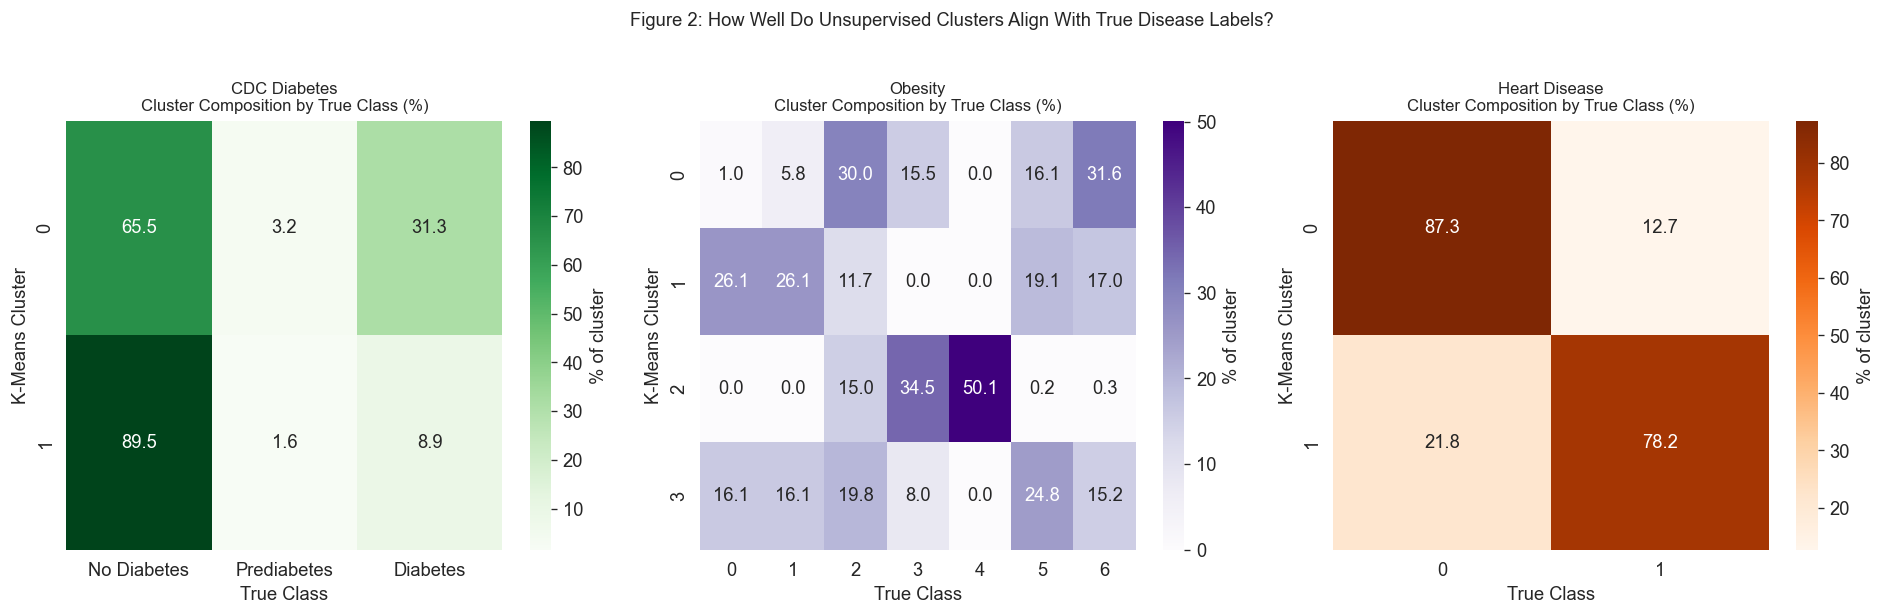

In [12]:
# Figure 2: Cluster composition heatmaps — visualizing alignment between clusters and true labels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, crosstab, ds_name, cmap in zip(
    axes, [crosstab1, crosstab2, crosstab3],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    ['Greens', 'Purples', 'Oranges']
):
    pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    sns.heatmap(pct, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar_kws={'label': '% of cluster'})
    ax.set_title(f'{ds_name}\nCluster Composition by True Class (%)', fontsize=10)
    ax.set_xlabel('True Class')
    ax.set_ylabel('K-Means Cluster')

plt.suptitle('Figure 2: How Well Do Unsupervised Clusters Align With True Disease Labels?', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week10_fig2_cluster_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 Interpretation

Figure 2 compares the K-Means clusters with the true disease labels to see how well the natural clusters match the actual classes.

For the CDC Diabetes dataset, the clusters do not align well with the three diabetes classes. One cluster is mostly people without diabetes, while the other contains a mixture of people without diabetes and diabetes. Most importantly, prediabetes is spread across both clusters instead of forming its own distinct group. I think this is the strongest finding in this notebook because it supports my earlier supervised learning results without using the labels during training.

For the Obesity dataset, the clusters show partial agreement with the true labels. Some neighboring obesity categories are grouped together, suggesting that similar obesity levels naturally overlap in the feature space rather than forming completely separate clusters.

For the Heart Disease dataset, the clusters align much better with the true labels. One cluster contains mostly patients without heart disease (87.3%), while the other contains mostly patients with heart disease (78.2%). Although the separation is not perfect, the results are consistent with the stronger supervised learning performance I observed in earlier weeks.
Overall, this figure provides independent evidence that the CDC Diabetes dataset has the most overlapping class structure. Even without using the disease labels, K-Means could not identify a separate prediabetes cluster, suggesting that the limitation lies in the structure of the data rather than the choice of machine learning algorithm.

# Answers to All Rubric Questions

## 1. How Did I Avoid Overfitting?

Although K-Means is an unsupervised algorithm and does not overfit in the same way as supervised models, I avoided choosing an arbitrary number of clusters by using both the elbow method and the silhouette score. I also standardized all features before clustering so that variables with larger scales would not dominate the distance calculations. For the large CDC Diabetes dataset, I used a stratified subsample of 15,000 observations to make the analysis computationally efficient while preserving the original class distribution.

## 2. Metrics Used

I used inertia and the silhouette score to evaluate the clustering results. Inertia measures how close observations are to their assigned cluster, while the silhouette score measures how well each observation fits within its cluster compared with neighboring clusters. I selected the value of K with the highest silhouette score for each dataset.

The optimal values were:

- CDC Diabetes: K = 2 (Silhouette = 0.2293)
- Obesity: K = 4 (Silhouette = 0.2216)
- Heart Disease: K = 2 (Silhouette = 0.1936)

After clustering, I compared the cluster assignments with the true class labels to evaluate how well the natural clusters matched the known disease groups.

## 3. Expected and Unexpected Findings

I expected the CDC Diabetes dataset to remain difficult because all of my supervised models reached a similar performance ceiling. The K-Means results supported that expectation. The clusters did not align well with the three diabetes classes, and prediabetes did not form a distinct cluster.

I was surprised that the Obesity dataset selected only four natural clusters even though it contains seven obesity categories. This suggests that several neighboring obesity levels naturally overlap. I was also encouraged that the Heart Disease clusters matched the binary labels reasonably well, which was consistent with its stronger supervised learning performance.

## 4. How Did EDA Help?

My earlier EDA helped explain these clustering results. The CDC Diabetes dataset showed overlapping classes and class imbalance, so I expected weak cluster separation. In contrast, the Obesity dataset showed clearer relationships between body measurements and obesity levels, while the Heart Disease dataset contained stronger clinical signals. These patterns were reflected in the final clustering results.

## 5. External Sources Used

In addition to the course materials, I used:

- StatQuest – K-Means Clustering Clearly Explained
- Scikit-learn documentation (KMeans and silhouette_score)
- Rousseeuw, P. J. (1987). Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis.

These resources helped me understand how to select the optimal number of clusters and interpret the clustering results.

# Week 10 Conclusions

This week's analysis helped answer my research question from an unsupervised learning perspective. The CDC Diabetes dataset did not naturally separate into three distinct groups, even when the disease labels were completely removed. This supports the findings from my earlier supervised learning models and suggests that the main challenge is the overlap between the diabetes classes rather than the choice of machine learning algorithm.
In contrast, the Obesity and Heart Disease datasets showed better agreement between the clusters and the true labels, which is consistent with their stronger supervised learning performance in previous weeks.